<a href="https://colab.research.google.com/github/melinda-ab/CVL_Assignment/blob/main/Assignment_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Computer Vision Assignment 01**
Melinda Annastasia Budijono (24/542840/PA/23052)

---

Perform an implementation for image enhancement in any image types (blurred image, dark image, bright image, low-contrast image, etc).


In [5]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

##**1. Low Contrast Image**

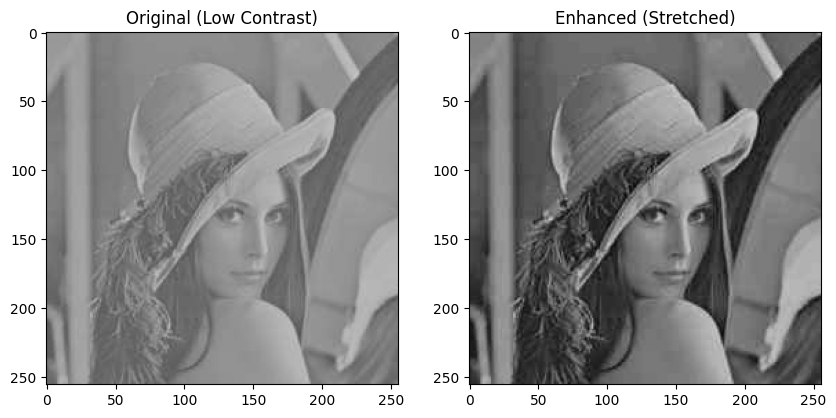

In [6]:
# 1. Load and Preprocess
image = cv.imread('low_contrast_image.jpg')
h, w = 256, 256
image = cv.resize(image, (w, h))
image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

# 2. Define the Target Range
a, b = 0, 225

# 3. Calculate Min and Max
sourcemin = image.min()
sourcemax = image.max()

# 4. Perform Contrast Stretching
# Vectorized approach: (image - min) * (range / source_range) + offset
contrast_streaching = (image.astype(float) - sourcemin) * ((b - a) / (sourcemax - sourcemin)) + a
contrast_streaching = np.uint8(contrast_streaching)

# 5. Visualization
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original (Low Contrast)")
plt.imshow(image, cmap='gray', vmin=0, vmax=255)

plt.subplot(1, 2, 2)
plt.title("Enhanced (Stretched)")
plt.imshow(contrast_streaching, cmap='gray', vmin=0, vmax=255)

plt.show()

Berdasarkan percobaan ini, telah dilakukan teknik **Contrast Stretching** untuk mengatasi masalah *low-contrast* pada citra. Dalam proses ini, setiap nilai intensitas pixel dilakukan *remapping* secara linear ke dalam target range 0-255. Tujuannya adalah untuk memperlebar distribusi histogram sehingga detail objek pada citra menjadi lebih tegas dan jelas.

##**2. Noisy Image**


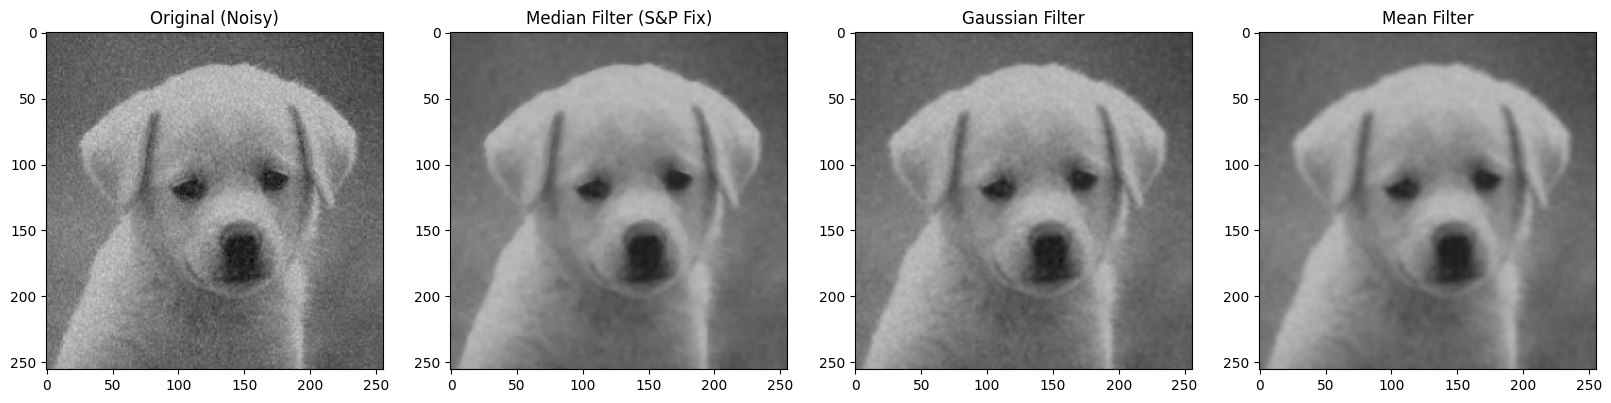

In [7]:
# 1. Load and Preprocess
image = cv.imread('noisy_image.jpeg')
image = cv.resize(image, (w, h))
image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

# 2. Apply Median Blur
denoised_median = cv.medianBlur(image, 5)

# 3. Apply Gaussian Blur
denoised_gaussian = cv.GaussianBlur(image, (5, 5), 0)

# 3. Apply Mean Blur
denoised_mean = cv.blur(image, (5, 5))

# 5. Visualization
plt.figure(figsize=(20, 5))
plt.subplot(1, 4, 1)
plt.title("Original (Noisy)")
plt.imshow(image, cmap='gray', vmin=0, vmax=255)

plt.subplot(1, 4, 2)
plt.title("Median Filter (S&P Fix)")
plt.imshow(denoised_median, cmap='gray', vmin=0, vmax=255)

plt.subplot(1, 4, 3)
plt.title("Gaussian Filter")
plt.imshow(denoised_gaussian, cmap='gray', vmin=0, vmax=255)

plt.subplot(1,4,4)
plt.title("Mean Filter")
plt.imshow(denoised_mean, cmap='gray', vmin=0, vmax=255)

plt.show()

Percobaan ini menunjukkan **Median Blur**, **Gaussian Blur**, dan **Mean Blur** untuk menangani *noise* pada citra. *Median Blur* bekerja dengan mencari nilai tengah dari area 5x5 (25 pixel) untuk menggantikan pixel pusat. Sementara itu, *Gaussian Blur* melakukan penghalusan dengan rata-rata berbobot dan *Mean Filter* bekerja dengan menghitung rata-rata aritmatika sederhana dari seluruh pixel di dalam kernel. Karena citra ini tergolong memiliki *salt and pepper noise*, *Median Blur* terbukti jauh lebih efektif karena mampu membuang nilai ekstrem (hitam/putih) sepenuhnya, sementara *Gaussian Blur* dan *Mean Blur* hanya mengaburkan noise tersebut tanpa menghilangkannya.

##**3. Too Dark (Underexpose)**




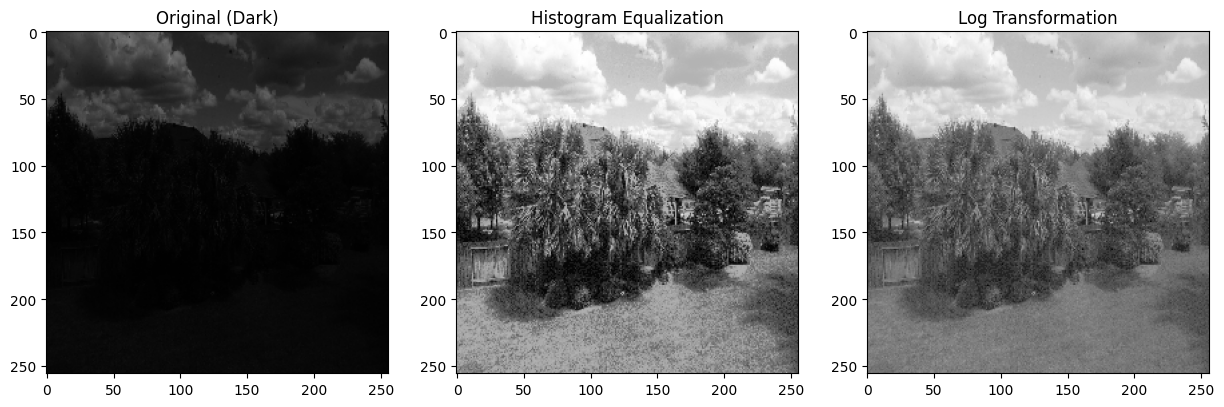

In [10]:
# 1. Load and Preprocess
image = cv.imread('too_dark_image.jpg')
image = cv.resize(image, (w, h))
image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

# 1. Apply Histogram Equalization (HE)
he_underexpose = cv.equalizeHist(image)

# 2. Apply Log Transformation
c = 255 / np.log(1 + np.max(image)) # Scaling constant
log_underexpose = c * (np.log(image.astype(np.float32) + 1))
log_underexpose = np.uint8(log_underexpose) # Convert back to 8-bit

# 4. Visualization
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Original (Dark)")
plt.imshow(image, cmap='gray', vmin=0, vmax=255)

plt.subplot(1, 3, 2)
plt.title("Histogram Equalization")
plt.imshow(he_underexpose, cmap='gray', vmin=0, vmax=255)

plt.subplot(1, 3, 3)
plt.title("Log Transformation")
plt.imshow(log_underexpose, cmap='gray', vmin=0, vmax=255)

plt.show()

Berdasarkan hasil percobaan, untuk citra yang *underexposed* (terlalu gelap), **Histogram Equalization** serta **Log Transformation** dapat dilakukan untuk mengatasi masalah tersebut. Dalam contoh ini, HE menghasilkan hasil yang lebih tajam karena meregangkan rentang piksel gelap secara maksimal ke seluruh jangkauan dinamis 0-255, sehingga kontras global meningkat drastis. Sebaliknya, LT justru mengompresi nilai keluaran ke rentang abu-abu yang sempit, sehingga gambar terlihat lebih 'pucat' dan kurang mendetail dibandingkan hasil HE yang memiliki kontras tinggi.

##**4. Too Bright (Overexpose)**

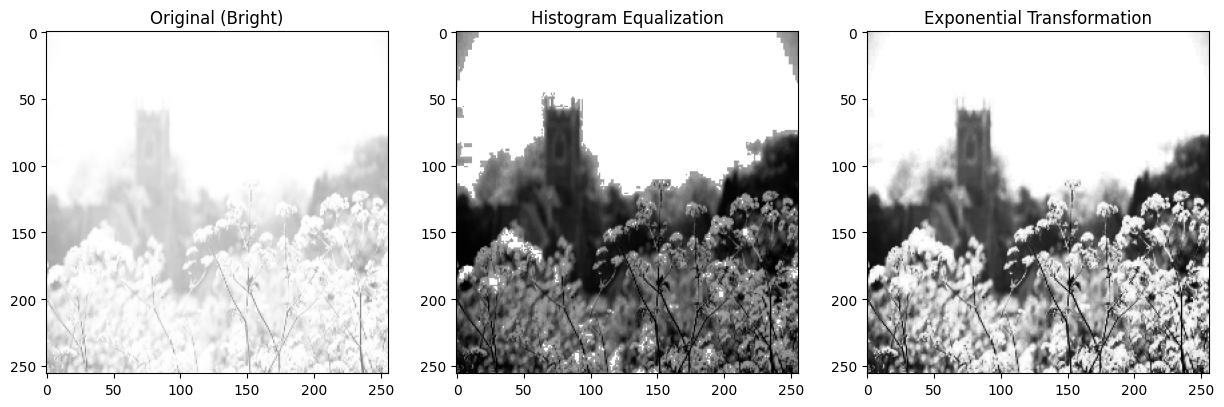

In [11]:
# 1. Load and Preprocess
image = cv.imread('too_bright_image.jpg')
image = cv.resize(image, (w, h))
image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

# 1. Apply Histogram Equalization (HE)
he_overexpose = cv.equalizeHist(image)

# 2. Apply Exponential Transformation
gamma = 7.0 # > 1 to darken the image
# Normalizing to 0-1 range, applying power, then scaling back to 0-255
exp_overexpose = np.array(255 * (image / 255) ** gamma, dtype='uint8')

# 4. Visualization
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Original (Bright)")
plt.imshow(image, cmap='gray', vmin=0, vmax=255)

plt.subplot(1, 3, 2)
plt.title("Histogram Equalization")
plt.imshow(he_overexpose, cmap='gray', vmin=0, vmax=255)

plt.subplot(1, 3, 3)
plt.title("Exponential Transformation")
plt.imshow(exp_overexpose, cmap='gray', vmin=0, vmax=255)

plt.show()

Berdasarkan percobaan pada citra yang overexposed, teknik **Histogram Equalization (HE)** dan **Exponential Transformation** digunakan untuk mengembalikan detail yang hilang akibat cahaya berlebih. HE bekerja secara otomatis meningkatkan kontras, namun pada citra ini menghasilkan beberapa area yang terlihat kurang natural atau 'pecah'.Di sisi lain, ET  dengan nilai $\gamma$ = 7 terbukti sangat efektif untuk mereduksi intensitas cahaya. Penggunaan gamma yang tinggi (7) memungkinkan detail objek menjadi lebih jelas dibandingkan citra aslinya.

##**5. Blurry**

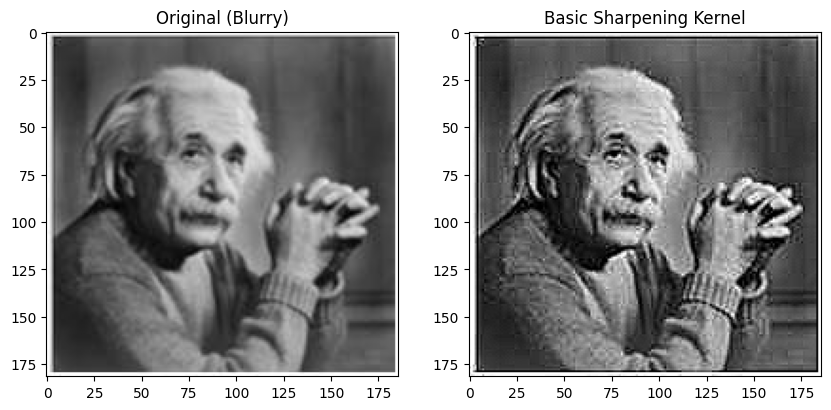

In [12]:
# 1. Load the blurry image
image = cv.imread('blurry_image.jpg')
image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

# 2. Apply Basic Sharpening Kernel
# Define a sharpening kernel
kernel = np.array([[0, -1, 0],
                   [-1, 5, -1],
                   [0, -1, 0]])
sharpened_kernel = cv.filter2D(image, -1, kernel)

# 3. Visualization
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original (Blurry)")
plt.imshow(image, cmap='gray', vmin=0, vmax=255)

plt.subplot(1, 2, 2)
plt.title("Basic Sharpening Kernel")
plt.imshow(sharpened_kernel, cmap='gray', vmin=0, vmax=255)

plt.show()

Untuk citra yang *blurry*, dapat dilakukan teknik **Basic Sharpening Kernel**. Teknik ini bekerja dengan menerapkan operasi konvolusi menggunakan matriks penajam yang memperkuat perbedaan intensitas piksel bertetangga, sehingga garis-garis pada citra terlihat lebih tegas. Namun, pada tingkat blur yang sangat parah, teknik ini memiliki keterbatasan karena dapat memunculkan artefak atau noise tambahan.

##**6. Uneven Illumination**

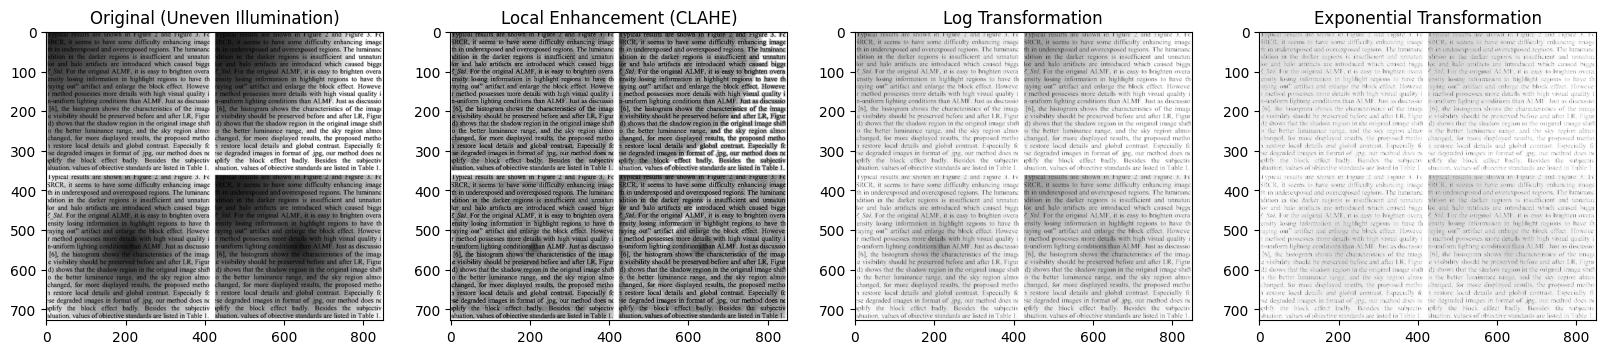

In [13]:
# 1. Load the image with uneven illumination
image = cv.imread('uneven_illumination.png', 0)
image_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)

# 2. Apply Local Enhancement (CLAHE)
clahe = cv.createCLAHE(clipLimit=28.0, tileGridSize=(32,32))
local_enhanced = clahe.apply(image)

# 3. Apply Log Transformation
log_illumination = np.log(1 + image.astype(np.float32))
cv.normalize(log_illumination, log_illumination, 0, 255, cv.NORM_MINMAX)
log_illumination = np.uint8(log_illumination)

# 4. Apply Exponential Transformation
gamma_bright = 0.1
exp_illumination = np.array(255 * (image.astype(np.float32) / 255) ** gamma_bright, dtype='uint8')

# 5. Visualization
plt.figure(figsize=(20, 5))
plt.subplot(1, 4, 1)
plt.title("Original (Uneven Illumination)")
plt.imshow(image, cmap='gray', vmin=0, vmax=255)

plt.subplot(1, 4, 2)
plt.title("Local Enhancement (CLAHE)")
plt.imshow(local_enhanced, cmap='gray', vmin=0, vmax=255)

plt.subplot(1, 4, 3)
plt.title("Log Transformation")
plt.imshow(log_illumination, cmap='gray', vmin=0, vmax=255)

plt.subplot(1,4,4)
plt.title("Exponential Transformation")
plt.imshow(exp_illumination, cmap='gray', vmin=0, vmax=255)

Untuk citra yang memiliki *uneven illumination*, dapat digunakan teknik **local enhancement**, **log transformation**, dan **exponential transformation**. Namub karena pada kasus ini citra memiliki gradasi bayangan yang sangat pekat dan ekstrem, maka diperlukan penyesuaian parameter yang lebih agresif. CLAHE ditingkatkan hingga clipLimit=28.0 untuk memaksa penguatan kontras pada area yang tertutup bayangan tebal agar detail teks muncul kembali. Sementara pada ET, digunakan nilai gamma_bright = 0.1 (Gamma Correction) untuk melakukan penarikan intensitas cahaya secara drastis pada piksel-piksel gelap sehingga distribusi pencahayaan di seluruh dokumen menjadi lebih seragam.

##**7. Too Sharp**

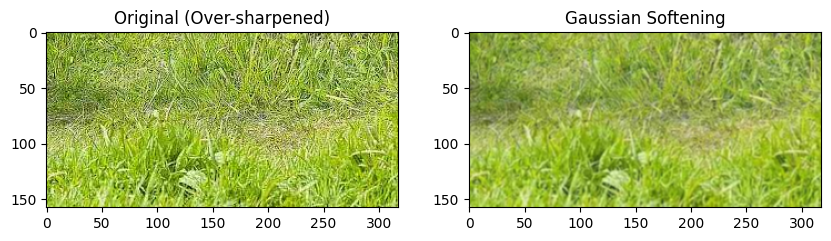

In [15]:
# 1. Load the over-sharpened image
image = cv.imread('too_sharp_image.jpeg')
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

# 2. Apply Gaussian Blur
gaussian_soft = cv.GaussianBlur(image, (3, 3), 0)

# 3. Visualization
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original (Over-sharpened)")
plt.imshow(image, cmap='gray', vmin=0, vmax=255)

plt.subplot(1, 2, 2)
plt.title("Gaussian Softening")
plt.imshow(gaussian_soft, cmap='gray', vmin=0, vmax=255)

plt.show()

Untuk citra yang mengalami *over-sharpening*, diterapkan teknik **Gaussian Softening**. Meskipun perbedaannya terlihat subtil, teknik ini berhasil mereduksi efek ringing atau ketajaman yang tidak natural pada tepi objek. Selain itu, penggunaan filter ini juga memberikan efek smoothing pada latar belakang, sehingga noise frekuensi tinggi hilang dan menghasilkan kualitas visual yang lebih halus serta natural dibandingkan citra aslinya yang terlalu tajam.

##**8. Low Resolution**


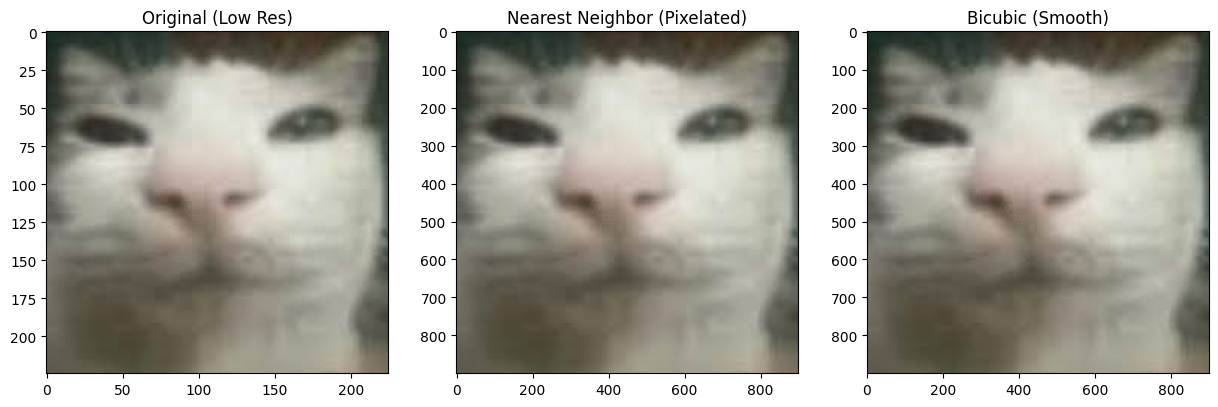

In [16]:
# 1. Load the low resolution image
image = cv.imread('low_resolution_image.jpeg')
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

# 2. Get original dimensions
height, width = image.shape[:2]

# 3. Upscale the image (e.g., 4x larger)
# We compare Nearest Neighbor (Bad) vs Bicubic (Good)
new_dim = (width * 4, height * 4)

# 4. Apply Nearest Neighbor (Blocky)
nearest = cv.resize(image, new_dim, interpolation=cv.INTER_NEAREST)

# 5. Bicubic Interpolation (Smooth)
bicubic = cv.resize(image, new_dim, interpolation=cv.INTER_CUBIC)

# 4. Visualization
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Original (Low Res)")
plt.imshow(image, cmap='gray', vmin=0, vmax=255)

plt.subplot(1, 3, 2)
plt.title("Nearest Neighbor (Pixelated)")
plt.imshow(nearest, cmap='gray', vmin=0, vmax=255)

plt.subplot(1, 3, 3)
plt.title("Bicubic (Smooth)")
plt.imshow(bicubic, cmap='gray', vmin=0, vmax=255)

plt.show()


Untuk mengatasi citra dengan resolusi rendah, dapat diterapkan teknik Nearest Neighbor dan Bicubic Interpolation yang memiliki perbedaan kualitas hasil cukup signifikan. Teknik Nearest Neighbor bekerja dengan cara menduplikasi nilai piksel terdekat sehingga menghasilkan perbesaran yang tampak kasar dan pecah (pixelated), sementara Bicubic Interpolation mampu menghasilkan citra yang jauh lebih halus (smooth) dengan melakukan perhitungan polinomial dari 16 piksel tetangga untuk menciptakan transisi warna yang lebih natural saat proses upscaling dilakukan.